In [2]:
import pandas as pd 
import os
import glob
import sys
import matplotlib.pyplot as plt 
import seaborn as sns
sys.path.append(os.path.abspath(os.path.join('..')))
import sqlite3
from config import DATABASE_PATH,DATASETS

Load latest csv Dataset

In [3]:
def latest_file():
    file_path = glob.glob(os.path.join(DATASETS,"*.csv"))
    if not file_path:
        return None
    else:
        latest = max(file_path,key=os.path.getmtime)
        df = pd.read_csv(latest)
        return df

convert to DATAFRAME

In [4]:
try:
     df = pd.DataFrame(latest_file())
     print(df)
except Exception as e:
     print(f"{e} no data avilable")


      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

connect to database

In [5]:
try:
    conn = sqlite3.connect(DATABASE_PATH)
    print('connection stablish')
    print(pd.read_sql('select*from Telco_customer_table limit 3;',conn))
except Exception as e:
    print(e)

connection stablish
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   
2          No          No              No  Month-to-month              Yes   

      PaymentMethod MonthlyCharges  Total

Normal EDA

In [6]:
# null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
#check nan value
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# there is some nane value in Total charges 

In [9]:
# duplicate values
df.duplicated().sum()

np.int64(0)

In [10]:
# dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Numeric Data EDA

In [12]:
df.select_dtypes(include='number')

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [13]:
df.select_dtypes(include="int")

,SeniorCitizen,tenure
0,0,1
1,0,34
2,0,2
3,0,45
4,0,2
...,...,...
7038,0,24
7039,0,72
7040,0,11
7041,1,4


In [14]:
# Senior Citizen
df['SeniorCitizen'].describe()

count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64

In [15]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

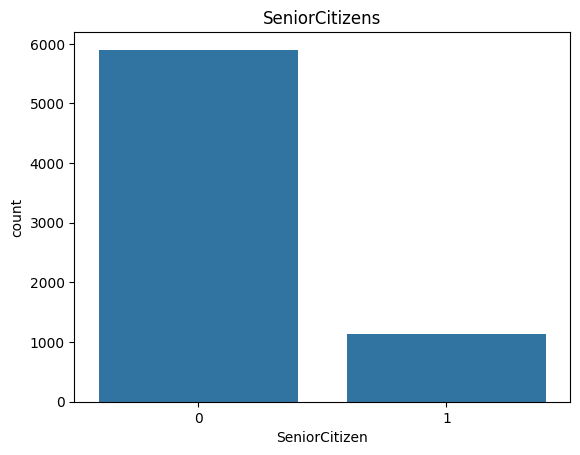

In [16]:
sns.countplot(data=df,x="SeniorCitizen")
plt.title('SeniorCitizens')
plt.show()

In [17]:
# Most of the customer are not a SeniorCitizen thats means most of the customers who use our telecom services are young,adult etc and very
# less customers are SeniorCitizens

In [18]:
# tenure
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

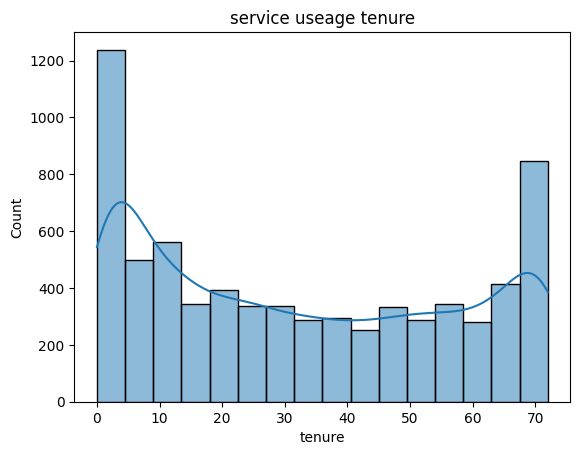

In [19]:
sns.histplot(df["tenure"],kde=True)
plt.title("service useage tenure")
plt.show()

In [20]:
# Most of the customer use our services only for 0 to 5 tenure
# and also most of the customer use our services for 70 tenure 
# and very less customer use our services for 10 to 60 tenure

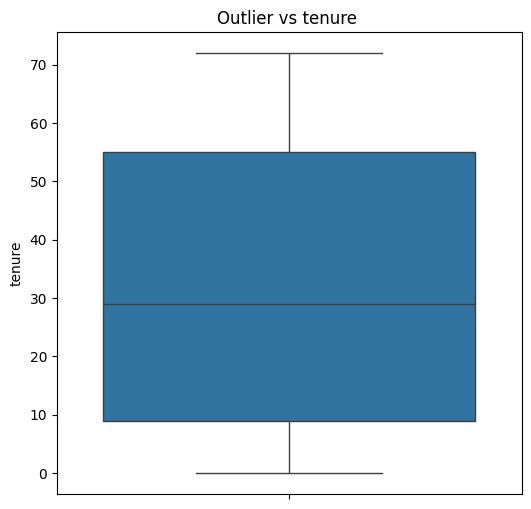

In [21]:
plt.figure(figsize=(6,6))
plt.title("Outlier vs tenure ")
sns.boxplot(df["tenure"])
plt.show()

In [22]:
# MonthlyCharges
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [23]:
df["MonthlyCharges"]

0        29.85
1        56.95
2        53.85
3        42.30
4        70.70
         ...  
7038     84.80
7039    103.20
7040     29.60
7041     74.40
7042    105.65
Name: MonthlyCharges, Length: 7043, dtype: float64

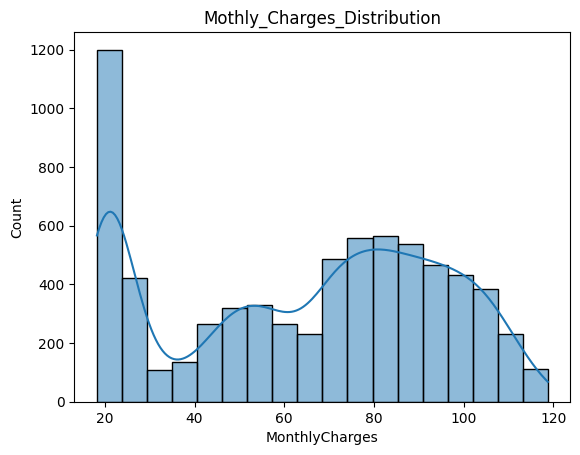

In [24]:
sns.histplot(df["MonthlyCharges"],kde=True)
plt.title("Mothly_Charges_Distribution")
plt.show()

In [25]:
# most of the customer monthly charges is 20 and between 70 to 100 and these customer are mostly does who's tenure is 
# between 0 to 10 and 70

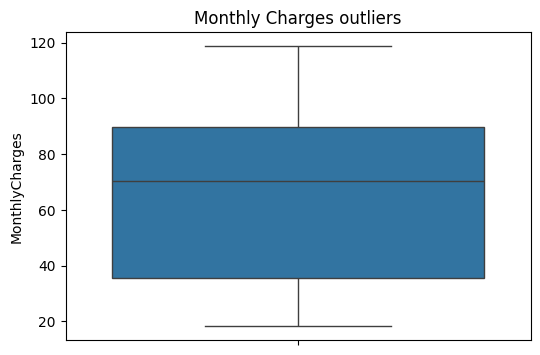

In [26]:
# outlier
plt.figure(figsize=(6,4))
plt.title("Monthly Charges outliers")
sns.boxplot(df["MonthlyCharges"])
plt.show()

In [27]:
# convert TotalCahrges from str to int 
df["TotalCharges"]

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str

In [28]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors='coerce')
df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

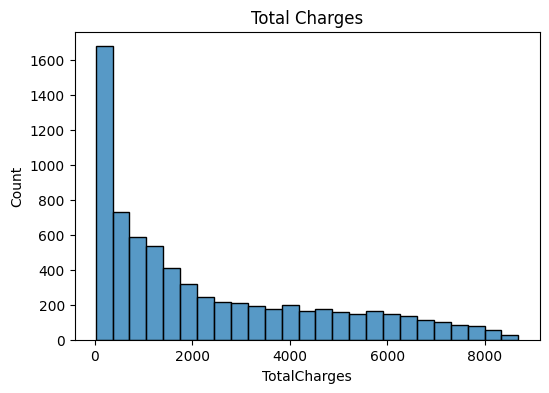

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(data = df, x = 'TotalCharges')
plt.title('Total Charges')
plt.show()

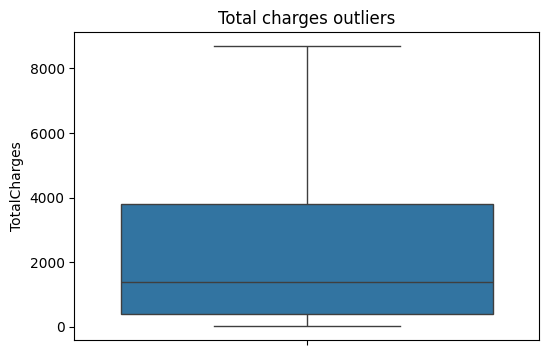

In [30]:
# outlier
plt.figure(figsize=(6,4))
plt.title("Total charges outliers")
sns.boxplot(df["TotalCharges"])
plt.show()

In [31]:
# In total charges there is no outlier but we see that most of the data present between 400 to 3000 

In [32]:
co = df.select_dtypes(include='str').columns
co

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

Categorical data EDA

In [33]:
# show all categorical features
cat_col = df.select_dtypes(include='str')
cat_col = cat_col.drop(["customerID"],axis=1)
cat_col

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [34]:
# make custom function for categoical Data

def plots(df,columns):
    if columns is None:
        print("NO COLUMNS AVILABLE")
    elif df is None:
        print("DATA IS NO AVILABLE")
    else:
        for i in columns:
            plt.figure(figsize=(6,6))
            plt.title(i)
            sns.histplot(data = df, x=i)
            plt.xticks(rotation=45,ha='right')
            plt.grid(True,axis='y')
            print(f"{i} \n {df[i].value_counts()}")
            plt.show()

gender 
 gender
Male      3555
Female    3488
Name: count, dtype: int64


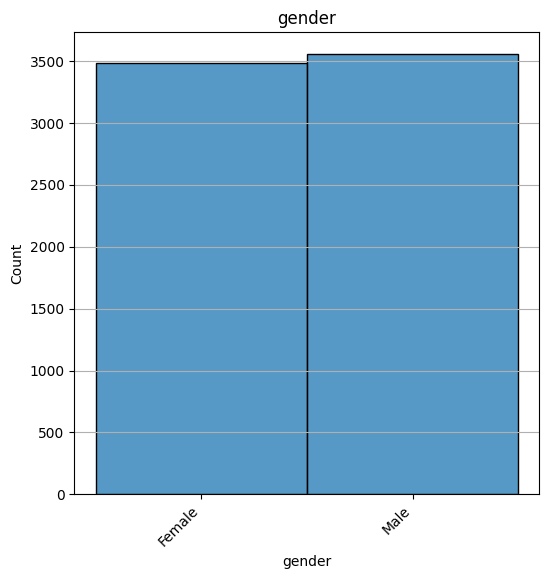

Partner 
 Partner
No     3641
Yes    3402
Name: count, dtype: int64


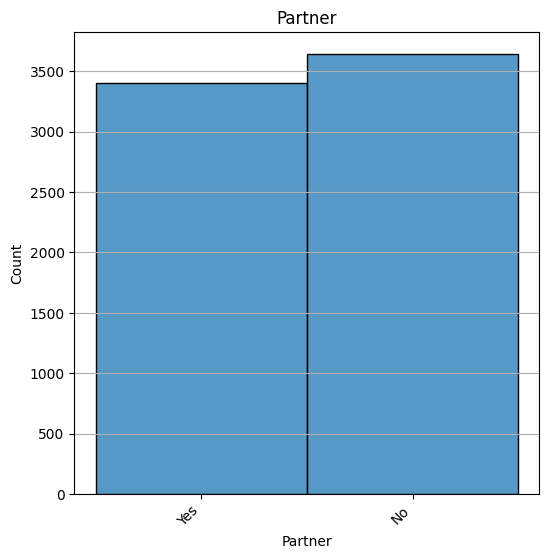

Dependents 
 Dependents
No     4933
Yes    2110
Name: count, dtype: int64


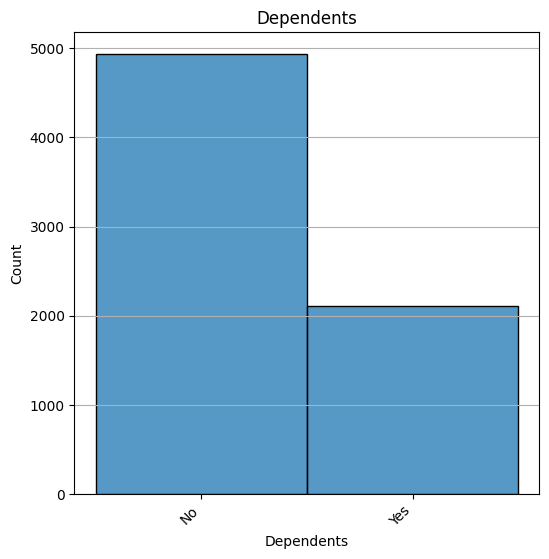

PhoneService 
 PhoneService
Yes    6361
No      682
Name: count, dtype: int64


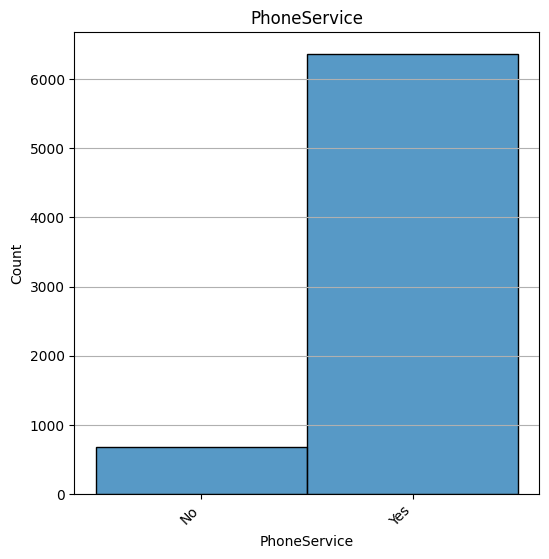

MultipleLines 
 MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


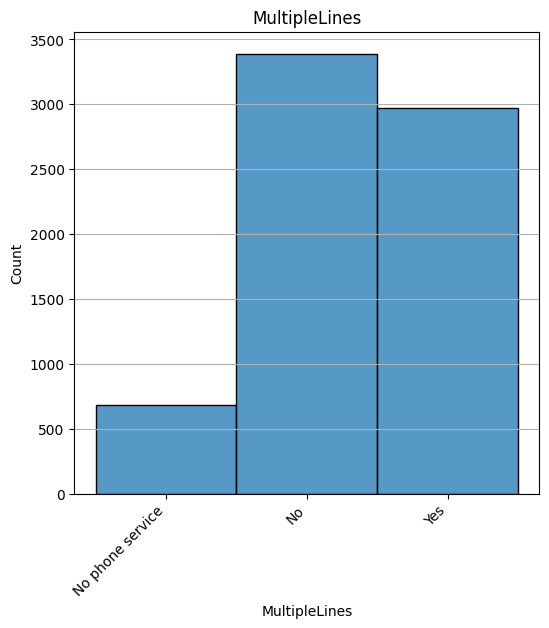

InternetService 
 InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


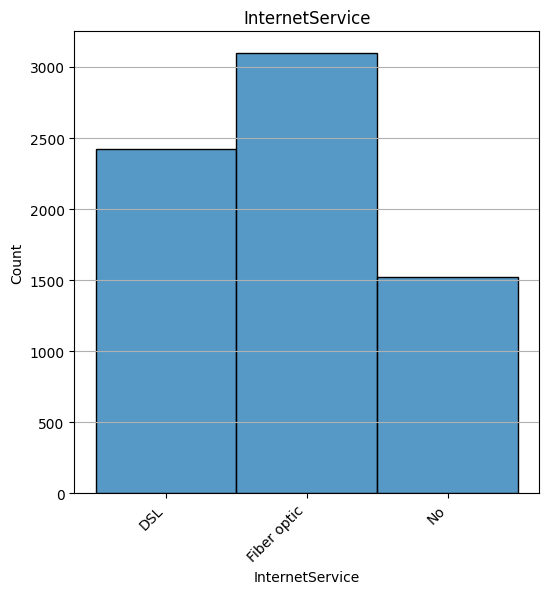

OnlineSecurity 
 OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


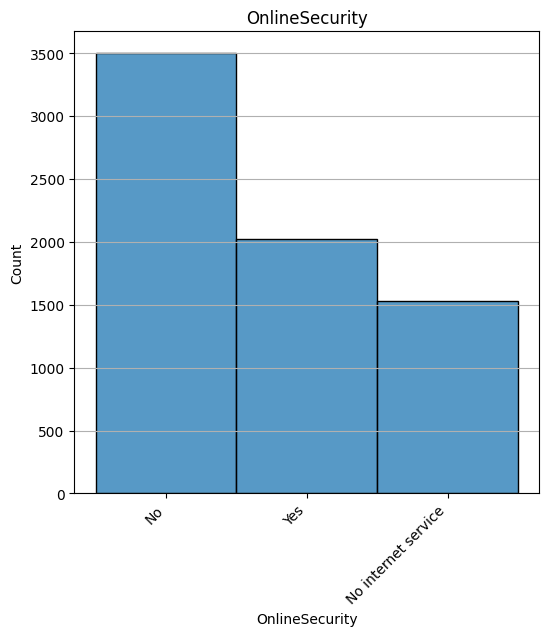

OnlineBackup 
 OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


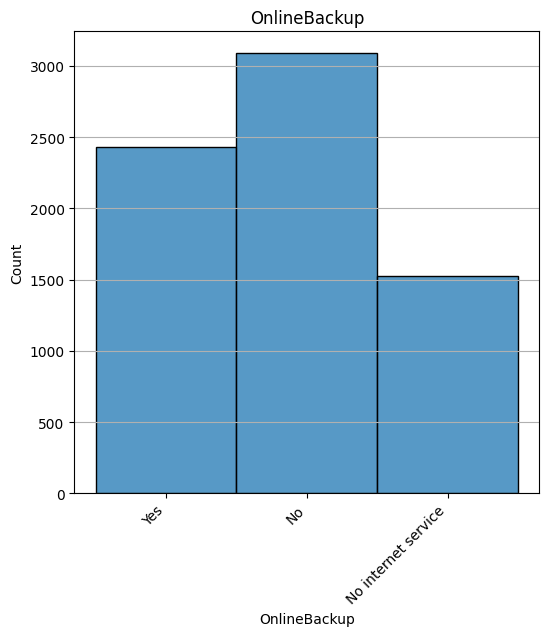

DeviceProtection 
 DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


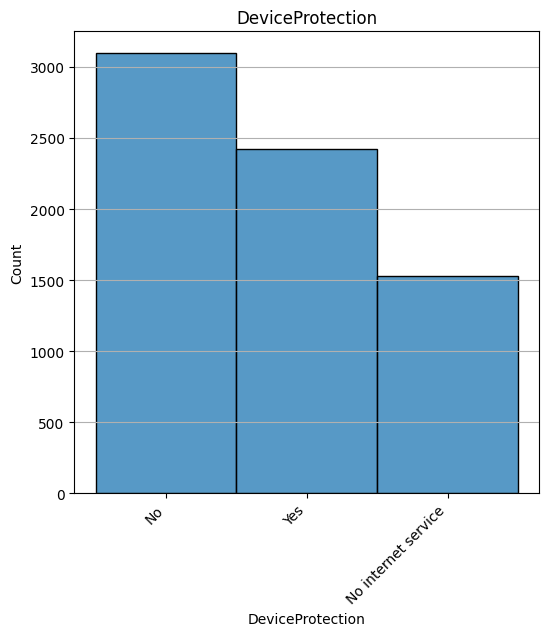

TechSupport 
 TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


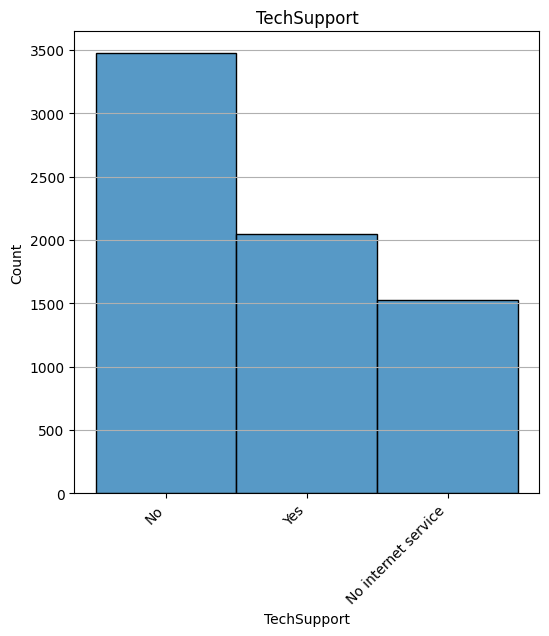

StreamingTV 
 StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64


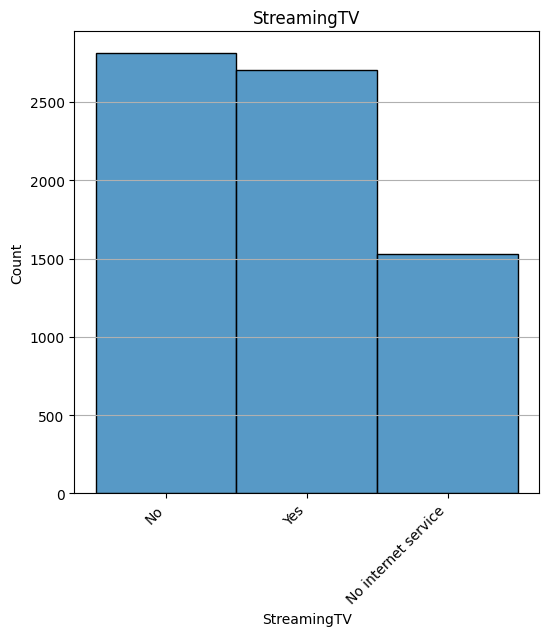

StreamingMovies 
 StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


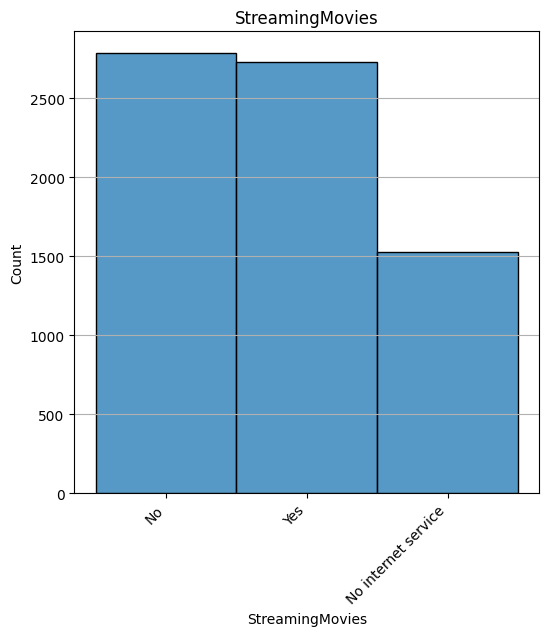

Contract 
 Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


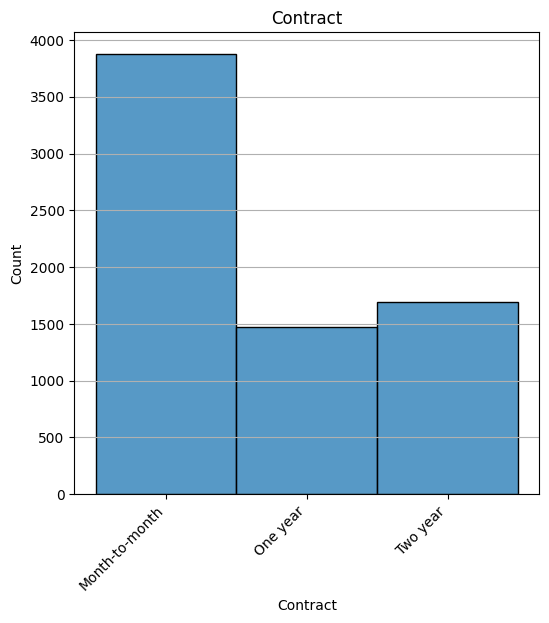

PaperlessBilling 
 PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


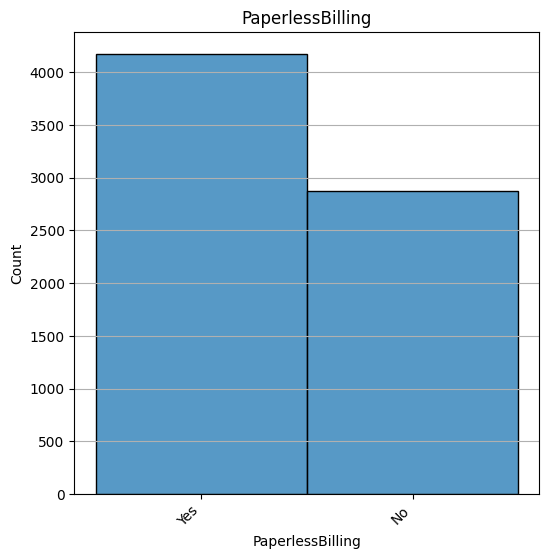

PaymentMethod 
 PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


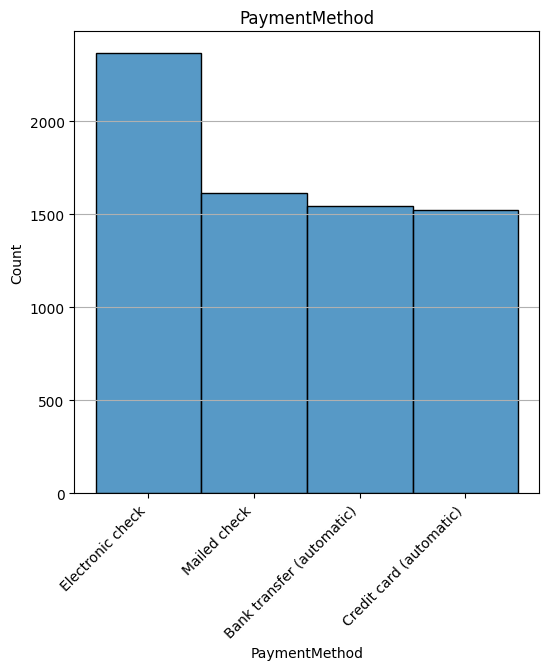

Churn 
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


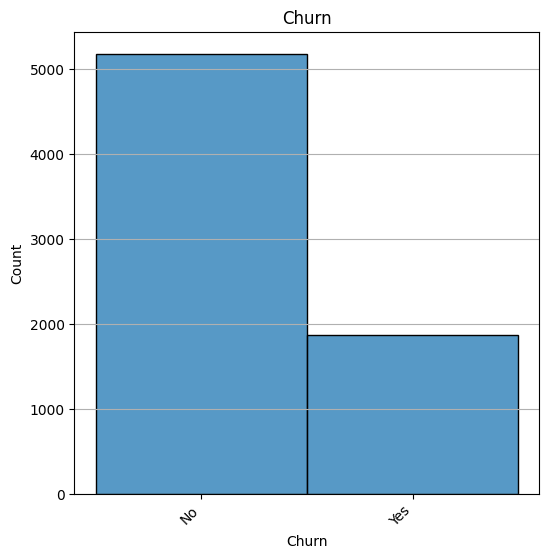

In [35]:
# Draw plots
plots(df,cat_col)

In [36]:
''' 
1.  gender : Male = 3555, Female = 3488 in Telcom dataset both male and female are balanced 
2.  Partner : No = 3641 , Yes = 3402 there is slightly higher number of customer who have no partners and partner data is also balanced
3.  Dependents: No = 4933, Yes = 2110 most of the customers are independent and these are teens or young customers and there is low dependents
                                 customers who are sinorcitizens
4.  PhoneService: Yes = 6361, No = 682 most of the customers use phoneservices and very less customer not use phoneservices
5.  MultipleLines: No = 3390, Yes = 2971, No phone service = 682 most of the customer not use multiplelines, and very less customer use phone
                                                                  services and who not use phoneServices also not use multipllines
6.  InternetService: Fiber optic = 3096, DSL = 2421,No = 1526 There is large number of custmer that use optic and less use DSL company should 
                      increase quality of internet service of DSL and very less customer not use andy internet services maybe these are
                      sinorcitizens 
7.  OnlineSecurity: No = 3498, Yes = 2019, No internet service = 1526 there is negative point large number of customer not take onlinesecurity
                     maybe due to high prices or not awarnes how onlineSecurity is important
8.  OnlineBackup: No = 3088, Yes = 2429, No internet service = 1526 same negative point but slitily better then onlineSecurity most of 
                   the customer not buy onlinebackup but most of the customer buy onlinebackup compare to onlinesecurity and very less 
                   customer not buy internet service so backup also not buy company should decrease price or give discount in onlinebackup
9.  DeviceProtection: No = 3095, Yes = 2422,No internet service = 1526 same like onlineBackup both values are slightly match

10. TechSupport: No = 3473,Yes = 2044, No internet service = 1526 most of the customer not use Techsupport and its a good sign because
                 in telcom company very less complain are registre or file but not fully resolve comapany should resolve customer problem
                 so customer not complain again.
11. StreamingTV: No = 2810,Yes = 2707, No internet service = 1526 there slightly little differnce between customer use or not use streamingTV
                 company should decrease the price or give good offers in streamingTV

12. StreamingMovies: No = 2785,Yes = 2732,No internet service = 1526 same like stremingTV there is slightly little difference between 
                      customer use streamingMovies or not use StreamingMovies and it directly correlated to price of streamingTV because
                      if customer not by streamingTV then customer also not watch streamingMovies

13. Contract: Month-to-month = 3875, Two year = 1695,One year = 1473 most of the customer by month-to-month contract compare to one or two year
                              there is a relation if customer use one year service then there is high chance customer also use two year contract
                              
14.  PaperlessBilling: Yes = 4171,No = 2872 most of the customer use paperlessbilling because they are teens or young and those who use
                        paper billing are sinorCitizen or customer who dont know about paperless billing so company help customer how to
                        use paper less billing.
15.  PaymentMethod: Electronic check = 2365, Mailed check = 1612, Bank transfer (automatic) = 1544, Credit card (automatic) = 1522
                    most of the customer use electronic check because it is cheaper compare to other methods and very equal number
                    of customer use other methods like mailed check, bank transfer and credit card.

16.  Churn: No = 5174,Yes = 1869 it is real positive sign that on the bases of data very less customer churn out and if company fixed issued
                 of streamingTV or other pricing and give good offers to customer, then there is high chance number of churn is decrease.
 


'''

' \n1.  gender : Male = 3555, Female = 3488 in Telcom dataset both male and female are balanced \n2.  Partner : No = 3641 , Yes = 3402 there is slightly higher number of customer who have no partners and partner data is also balanced\n3.  Dependents: No = 4933, Yes = 2110 most of the customers are independent and these are teens or young customers and there is low dependents\n                                 customers who are sinorcitizens\n4.  PhoneService: Yes = 6361, No = 682 most of the customers use phoneservices and very less customer not use phoneservices\n5.  MultipleLines: No = 3390, Yes = 2971, No phone service = 682 most of the customer not use multiplelines, and very less customer use phone\n                                                                  services and who not use phoneServices also not use multipllines\n6.  InternetService: Fiber optic = 3096, DSL = 2421,No = 1526 There is large number of custmer that use optic and less use DSL company should \n           

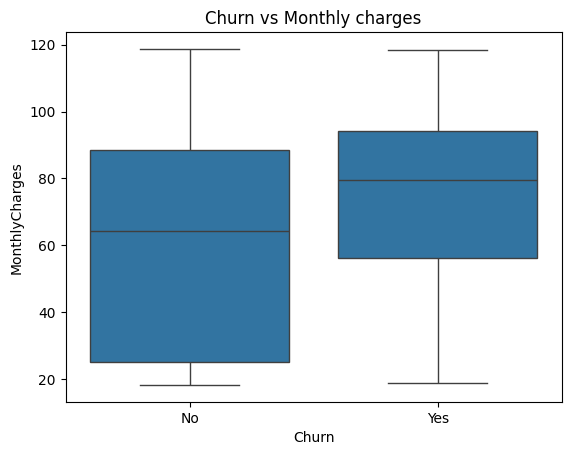

In [37]:
plt.Figure(figsize=(6,6))
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("Churn vs Monthly charges")
plt.show()

In [38]:
# churing customer average monthly charges around 60 to 90
# non churn customer average monthly charges around 30 to 85 

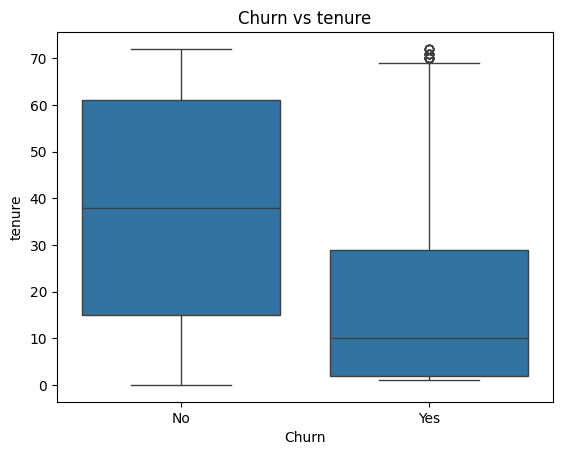

In [39]:
plt.Figure(figsize=(6,6))
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("Churn vs tenure")
plt.show()

In [40]:
# customer who not churn they have average tenure between 20 to 60
# and customer who churn most there average tenure between 5 to 25

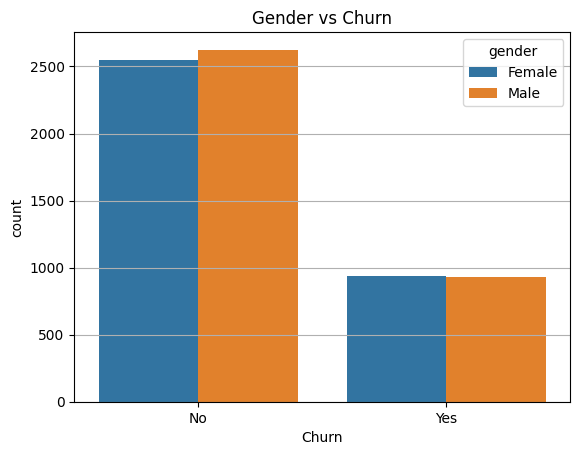

In [41]:
# check which gender churn most
plt.Figure(figsize=(6,8))
plt.title("Gender vs Churn")
sns.countplot(data =df,x="Churn",hue='gender')
plt.grid(True,axis='y')
plt.show()

In [42]:
# there is very little difference female churn slightly higher then male

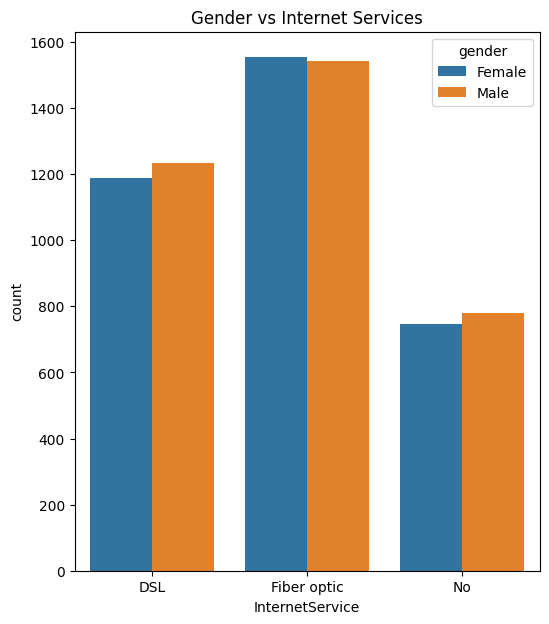

In [43]:
# check which gender use which internet services
plt.figure(figsize=(6,7))
plt.title("Gender vs Internet Services")
sns.countplot(data=df,x="InternetService",hue='gender')
plt.show()

In [44]:
# Most of the male and female use Fiber optic and less customer use DSL

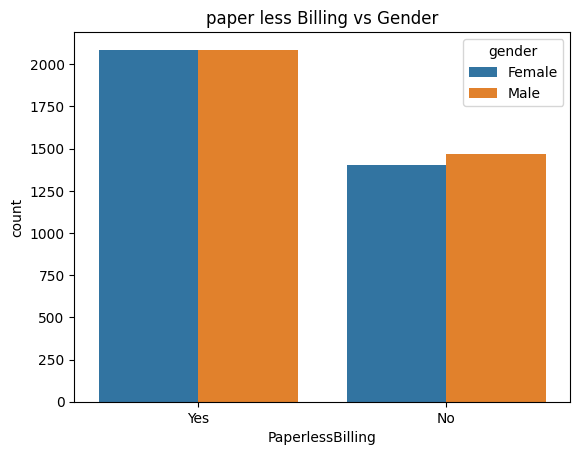

In [45]:
# Which gender use Paperlessbilling
plt.Figure(figsize=(6,5))
sns.countplot(data=df,x="PaperlessBilling",hue='gender')
plt.title('paper less Billing vs Gender')
plt.show()

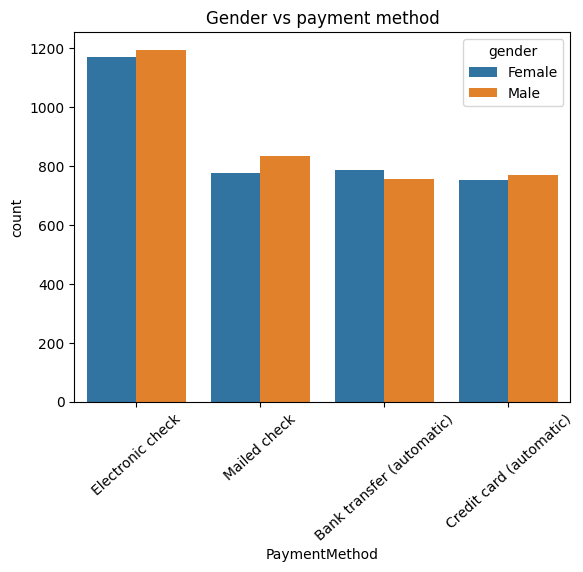

In [46]:
# gender vs payment methods
plt.Figure(figsize=(8,8))
sns.countplot(data = df, x='PaymentMethod',hue='gender')
plt.xticks(rotation = 42)
plt.title("Gender vs payment method")
plt.show()

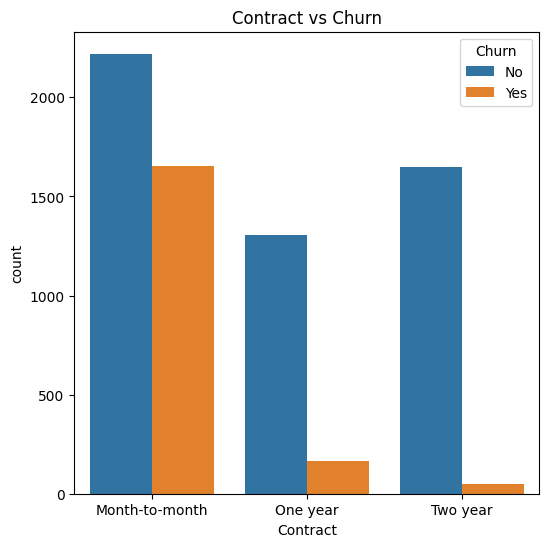

In [47]:
# contract VS churn
plt.figure(figsize=(6,6))
plt.title("Contract vs Churn")
sns.countplot(data=df,x="Contract",hue='Churn')
plt.show()

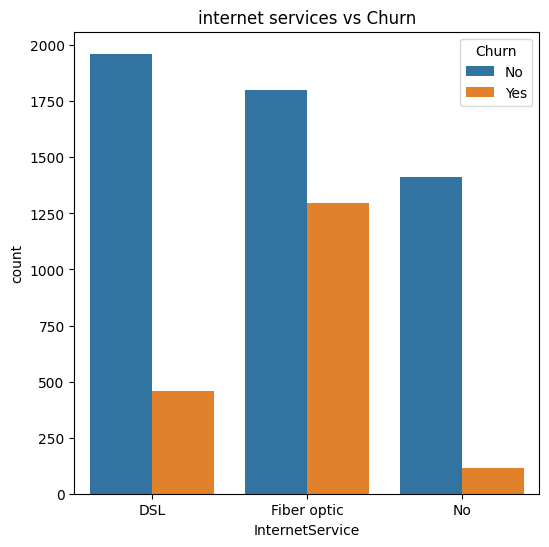

In [48]:
# internet services VS churn
plt.figure(figsize=(6,6))
plt.title("internet services vs Churn")
sns.countplot(data=df,x="InternetService",hue='Churn')
plt.show()

correlation

In [49]:
df['StreamingTV'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [50]:
df['StreamingMovies'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [51]:

d = pd.crosstab(df['StreamingMovies'],df['StreamingTV'],margins=True)
d

StreamingTV,No,No internet service,Yes,All
StreamingMovies,,,,
No,2018,0,767,2785
No internet service,0,1526,0,1526
Yes,792,0,1940,2732
All,2810,1526,2707,7043


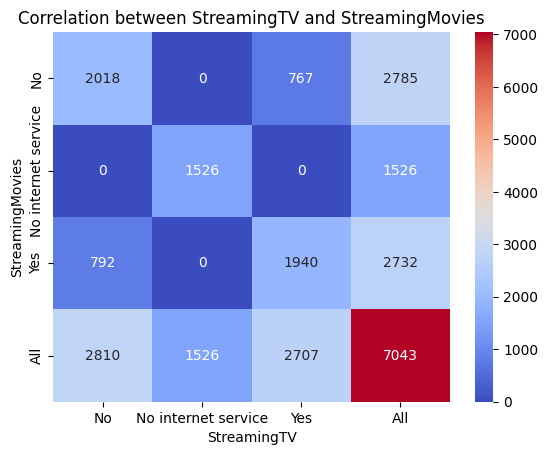

In [52]:

plt.Figure(figsize=(6,4))
plt.title("Correlation between StreamingTV and StreamingMovies")
sns.heatmap(d,annot=True,cmap='coolwarm',fmt='.0f')
plt.show()

In [53]:
# thats means 2018 customer not buy streamingTv and StreamingMovie and only 767 customer buy streamingmovie 
# and 2732 customer buy both streamingTV and SteamingMovie and 15626 customer not use internet so they also not use both

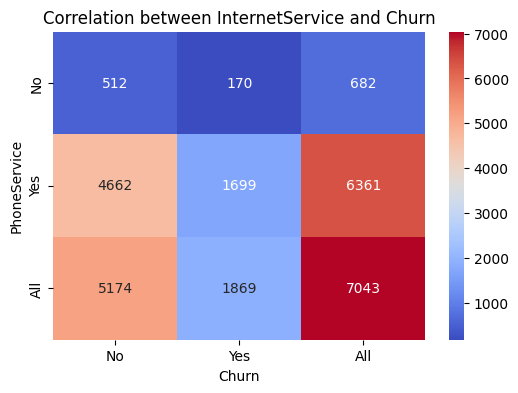

In [54]:
# correlation between PhoneServices and churns
corr = pd.crosstab(df['PhoneService'],df['Churn'],margins=True)
plt.figure(figsize=(6,4))
plt.title("Correlation between InternetService and Churn")
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.0f')
plt.show()


In [55]:
# 512 customer churn who not use internetServices and not churning only 170 customer not use internetservice and churning
# 4662 customer use internetservices and not churning and 16799 customer use internetservices and churing

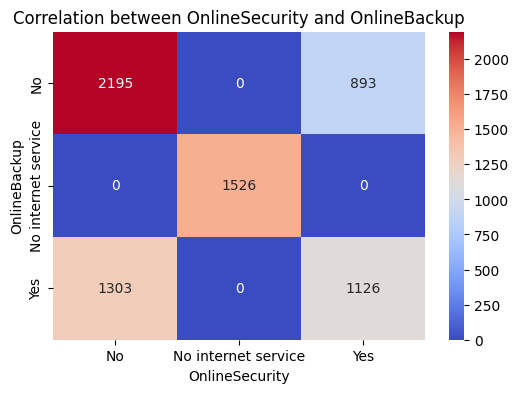

In [56]:
# correlation between  OnlineBackup and onlinesecurity
corr = pd.crosstab(df['OnlineBackup'],df["OnlineSecurity"])
plt.figure(figsize=(6,4))
plt.title("Correlation between OnlineSecurity and OnlineBackup")
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.0f')
plt.show()

In [57]:
# 2195 customer not buy both onlinesecurity and onlinebackup and only 895 customer buy onlinesecurity
# 1526 customer not but no internet service so they dont buy anything
# 1303 customer only buy online backup and 1126 customer buy both onlinesecuriy and onlinebackup

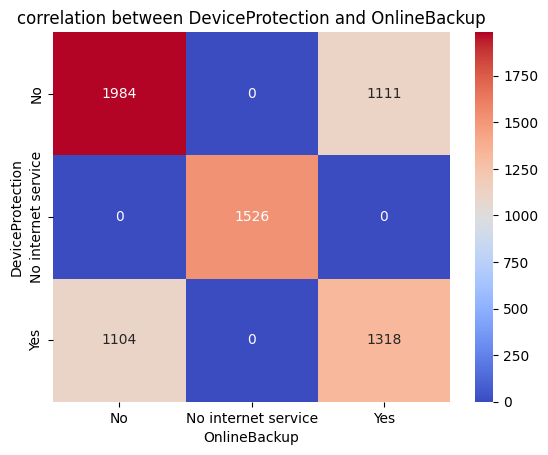

In [58]:
# Correlation between DeviceProtection and OnlineBackup


corr = pd.crosstab(df['DeviceProtection'],df["OnlineBackup"])
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.0f')
plt.title("correlation between DeviceProtection and OnlineBackup")
plt.show()

In [59]:
# 1984 customer not buy both DeviceProtection and onlinebackup and only 1111 customer buy onlineBackup
# 1526 customer not but no internet service so they dont buy anything
# 1104 customer only buy DeviceProtection and 1318 customer buy both DeviceProtection and onlinebackup

SQL Data insight

In [60]:
# average monthly and total price of InternetService
query = """ select InternetService,
round(avg(MonthlyCharges),2) as avg_Monthly_Charges,
round(avg(TotalCharges),2) as avg_Total_Charges
from Telco_customer_table group by InternetService;
"""
pd.read_sql(query,conn)

,InternetService,avg_Monthly_Charges,avg_Total_Charges
0,DSL,58.10,2115.41
1,Fiber optic,91.50,3205.30
2,No,21.08,662.60


In [61]:
# average monthly and total price OnlineSecurity
query = """select OnlineSecurity, 
 round(avg(MonthlyCharges),2) as avg_Monthly_Charges,
 round(avg(TotalCharges),2) as avg_Total_Charges
 from Telco_customer_Table where OnlineSecurity = 'Yes' ;"""
pd.read_sql(query,conn)



,OnlineSecurity,avg_Monthly_Charges,avg_Total_Charges
0,Yes,78.84,3751.59


In [62]:
# average monthly and total price OnlineBackup
query = """select OnlineBackup, 
 round(avg(MonthlyCharges),2) as avg_Monthly_Charges,
 round(avg(TotalCharges),2) as avg_Total_Charges
 from Telco_customer_Table where OnlineBackup = 'Yes' ;"""
pd.read_sql(query,conn)


,OnlineBackup,avg_Monthly_Charges,avg_Total_Charges
0,Yes,83.08,3870.54


In [63]:
# average monthly and total price DeviceProtection	
query = """select DeviceProtection	, 
 round(avg(MonthlyCharges),2) as avg_Monthly_Charges,
 round(avg(TotalCharges),2) as avg_Total_Charges
 from Telco_customer_Table where DeviceProtection= 'Yes' ;"""
pd.read_sql(query,conn)


,DeviceProtection,avg_Monthly_Charges,avg_Total_Charges
0,Yes,84.82,3913.98


In [64]:

# average monthly and total price  StreamingTV
query = """select  StreamingTV	, 
 round(avg(MonthlyCharges),2) as avg_Monthly_Charges,
 round(avg(TotalCharges),2) as avg_Total_Charges
 from Telco_customer_Table where  StreamingTV= 'Yes' ;"""
pd.read_sql(query,conn)


,StreamingTV,avg_Monthly_Charges,avg_Total_Charges
0,Yes,88.74,3757.03


In [65]:
# Number of customer in each tenure peroid
query = """ with vt as(
select customerID, case 
when tenure between 0 and 23 then "Small_tenure"
when tenure  between 23 and 46 then "Average_tenure"
else "Long_tenure" end as Tenure_Period from Telco_customer_table
) select Tenure_Period, count(*) as Count_customer from vt group by Tenure_Period order by count(*) desc;"""

pd.read_sql(query,conn)

,Tenure_Period,Count_customer
0,Small_tenure,3116
1,Long_tenure,2371
2,Average_tenure,1556


In [66]:
# check average TotalCharges and MonthlyCharges

query = """  with vt as(
select customerID, case 
when tenure between 0 and 23 then "Small_tenure"
when tenure  between 23 and 46 then "Average_tenure"
else "Long_tenure" end as Tenure_Period,
TotalCharges, MonthlyCharges
from Telco_customer_table
)
select Tenure_Period,
count(*) as total_Customer,
round(avg(MonthlyCharges),2) as avg_monthly_charges,
round(avg(TotalCharges),2) as avg_total_charges
from vt 
group by Tenure_Period order by count(*) desc;

"""
pd.read_sql(query,conn)

,Tenure_Period,total_Customer,avg_monthly_charges,avg_total_charges
0,Small_tenure,3116,57.67,518.74
1,Long_tenure,2371,73.51,4599.41
2,Average_tenure,1556,65.64,2271.57


Hypothesis Testing

In [67]:
from scipy.stats import ttest_ind

# monthly charges


# step 1: separate customer into two part
churn_yes = df[df['Churn']==1]['MonthlyCharges']
churn_No = df[df['Churn']==0]['MonthlyCharges']

# step 2: states the hypotheses
# h0 =  the average monthly charges are the same
# h1 = the average monthly charges are different

# step 3: Run the t-test

t_state, p_value = ttest_ind(churn_yes,churn_No)

C:\Users\hamen\AppData\Local\Temp\ipykernel_26116\3569452129.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_state, p_value = ttest_ind(churn_yes,churn_No)


In [68]:
# step 4: decision

alpha = 0.05

if p_value<alpha:
    print("reject_h0")
else:
    print("fail to reject h0")

fail to reject h0


In [69]:
# thats mean the average monthly charges are not same

In [70]:
# contract type affect churn or not

from scipy.stats import chi2_contingency
table = pd.crosstab(df['Contract'],df['Churn'])
table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [71]:
# h0 = contract type and churn are independent
# h1 = contract type and churn are dependent

# Run the test
chi2, p , dof, expected = chi2_contingency(table)
chi2 # larger value mean larger difference

np.float64(1184.5965720837926)

In [72]:
# step 4: decision

alpha = 0.05

if p<alpha:
    print("reject_h0")
else:
    print("fail to reject h0")

reject_h0


In [73]:
# thats mean contract type and churn are dependent and we have sufficent evidenece

In [74]:
# PhoneService and chrun are dependent or independent
table2 = pd.crosstab(df['PhoneService'],df["Churn"])
table2

Churn,No,Yes
PhoneService,,
No,512,170
Yes,4662,1699


In [75]:
# h0 = PhoneService and Churn are independent
# h1 = PhoneService and churn are dependent

chi2, P, dof, expected = chi2_contingency(table2)
chi2

np.float64(0.9150329892546948)

In [76]:


if P<alpha:
    print("reject_h0")
else:
    print("fail to reject h0")

fail to reject h0


In [77]:
# we do have sufficent evidence to reject ho thats mean phoneService and churn are independent

In [78]:
# tenure and churn are dependent or independent

# h0 = tenure and churn are independent
# h1 = tenure and churn are dependent

In [79]:
# step 1: separate customer into two part
Churn_yes = df[df['Churn']==1]['tenure']
Churn_No = df[df['Churn']==0]['tenure']

In [80]:
t_value,P_value = ttest_ind(Churn_yes,Churn_No)
t_value

C:\Users\hamen\AppData\Local\Temp\ipykernel_26116\351562823.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_value,P_value = ttest_ind(Churn_yes,Churn_No)


np.float64(nan)

In [81]:

if P_value<alpha:
    print("reject_h0")
else:
    print("fail to reject h0")

fail to reject h0


In [82]:
# we have sufficient evidence that tenure and churn are dependent